**STEP 1**

This dataset contains columns of different reservoir within *Chennai* the capital of *Tamil Nadu*. 

Within this dataset is 4 reservoir in Chennai and the date of which the level of water was collected **Mcft (one million cubic feet)**

We are trying to predict whether the water tank in that specific area will be filled with rain water or not at that date **indicating if they are at risk or not**

**STEP 2**

In [7]:
import pandas as pd
df = pd.read_csv("chennai_reservoir_levels.csv")

Data Understanding

In [8]:
df.head()

,Date,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
0,01-01-2004,3.9,0.0,268.0,0.0
1,02-01-2004,3.9,0.0,268.0,0.0
2,03-01-2004,3.9,0.0,267.0,0.0
3,04-01-2004,3.9,0.0,267.0,0.0
4,05-01-2004,3.8,0.0,267.0,0.0


In [9]:
df.shape

(6182, 5)

Here in df.info(), we can see that the "Date" columns Dtype is str, which should change to a **Date type**

We also notice that there are no non_null values in the dataset

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6182 entries, 0 to 6181
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             6182 non-null   str    
 1   POONDI           6182 non-null   float64
 2   CHOLAVARAM       6182 non-null   float64
 3   REDHILLS         6182 non-null   float64
 4   CHEMBARAMBAKKAM  6182 non-null   float64
dtypes: float64(4), str(1)
memory usage: 241.6 KB


Checking for null values, which is **NONE**

In [18]:
df.isnull().sum()

Date               0
POONDI             0
CHOLAVARAM         0
REDHILLS           0
CHEMBARAMBAKKAM    0
dtype: int64

Checking if our dataset has any duplicates, which returns that none have been found

In [14]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.describe()

,POONDI,CHOLAVARAM,REDHILLS,CHEMBARAMBAKKAM
count,6182.000000,6182.000000,6182.000000,6182.000000
mean,1106.739588,226.404589,1592.321652,1321.460555
std,1004.555050,266.886855,915.243744,951.791133
min,0.900000,0.000000,0.000000,0.000000
25%,202.000000,26.000000,847.250000,459.250000
50%,783.150000,89.000000,1685.000000,1264.000000
75%,1918.000000,411.000000,2320.000000,2046.750000
max,3231.000000,896.000000,3300.000000,3396.000000


Find out the outliers using the **IQR method**

As you can see there are no outliers in our dataset

In [23]:
for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    print(f"\n--- {col} ---")
    print(f"Bounds: {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"Outliers ({len(outliers)}):")
    print(outliers)


--- POONDI ---
Bounds: -2372.00 to 4492.00
Outliers (0):
Series([], Name: POONDI, dtype: float64)

--- CHOLAVARAM ---
Bounds: -551.50 to 988.50
Outliers (0):
Series([], Name: CHOLAVARAM, dtype: float64)

--- REDHILLS ---
Bounds: -1361.88 to 4529.12
Outliers (0):
Series([], Name: REDHILLS, dtype: float64)

--- CHEMBARAMBAKKAM ---
Bounds: -1922.00 to 4428.00
Outliers (0):
Series([], Name: CHEMBARAMBAKKAM, dtype: float64)


**STEP 3**

Fixing the date format to Date Dtype 

In [44]:
df["Date"]=pd.to_datetime(df["Date"],format='%d-%m-%Y')
df = df.sort_values('Date')

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6182 entries, 0 to 6181
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             6182 non-null   datetime64[us]
 1   POONDI           6182 non-null   float64       
 2   CHOLAVARAM       6182 non-null   float64       
 3   REDHILLS         6182 non-null   float64       
 4   CHEMBARAMBAKKAM  6182 non-null   float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 241.6 KB


**STEP 4**

**EDA**

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

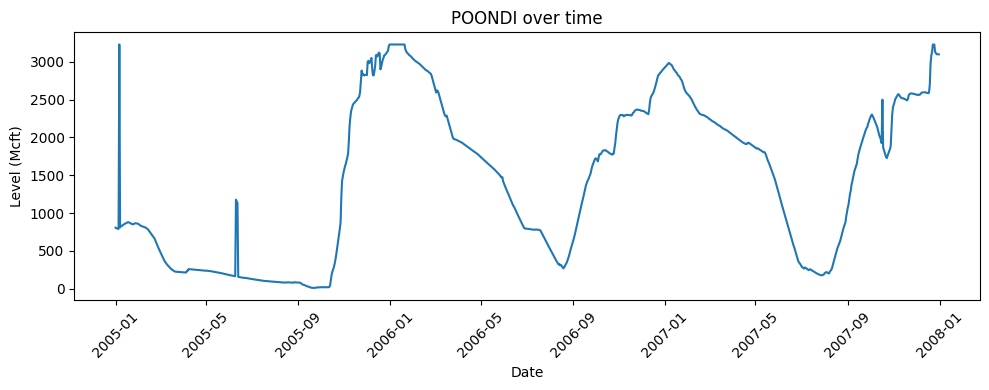

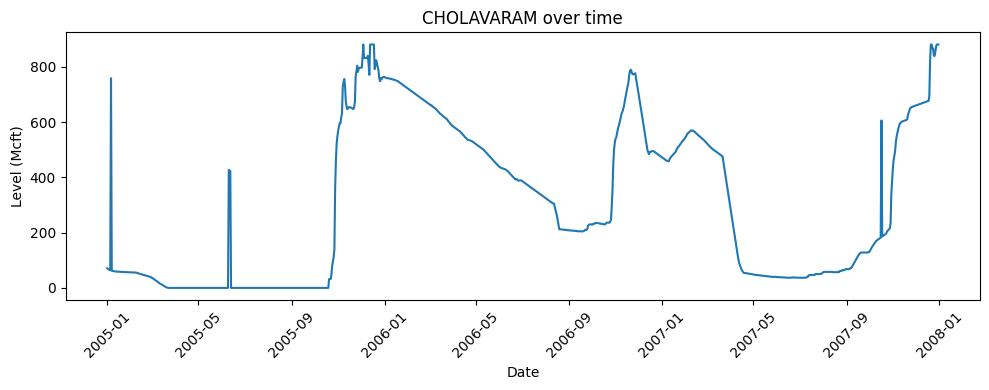

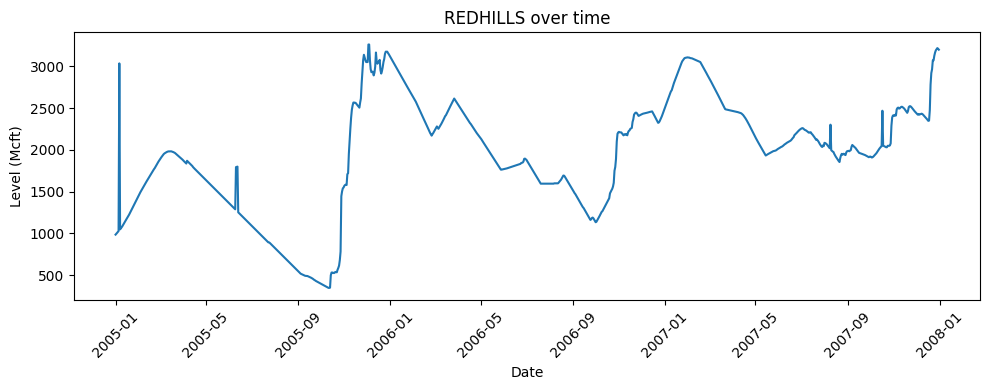

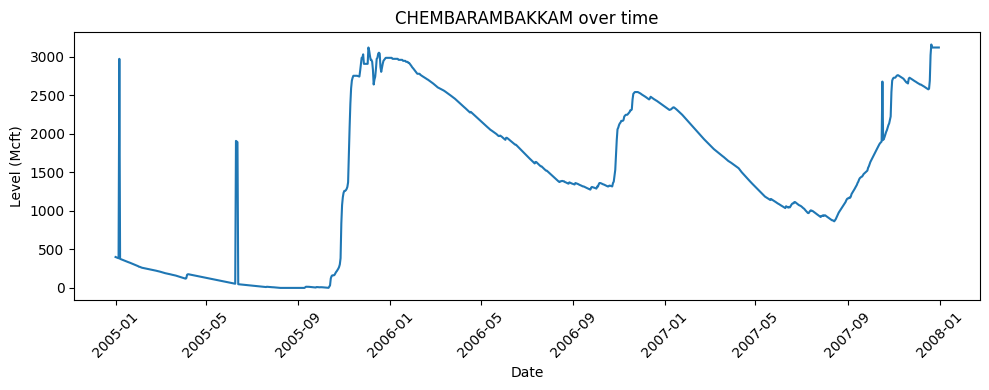

In [48]:
numeric_cols = df.select_dtypes(include='number').columns
df_2yr = df[(df['Date'] >= '2005-01-01') & (df['Date'] <= '2007-12-31')]
for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    plt.plot(df_2yr["Date"], df_2yr[col])
    plt.xlabel('Date')
    plt.ylabel("Level (Mcft)")
    plt.title(f'{col} over time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [53]:
reservoirs = ['POONDI', 'CHOLAVARAM', 'REDHILLS', 'CHEMBARAMBAKKAM']

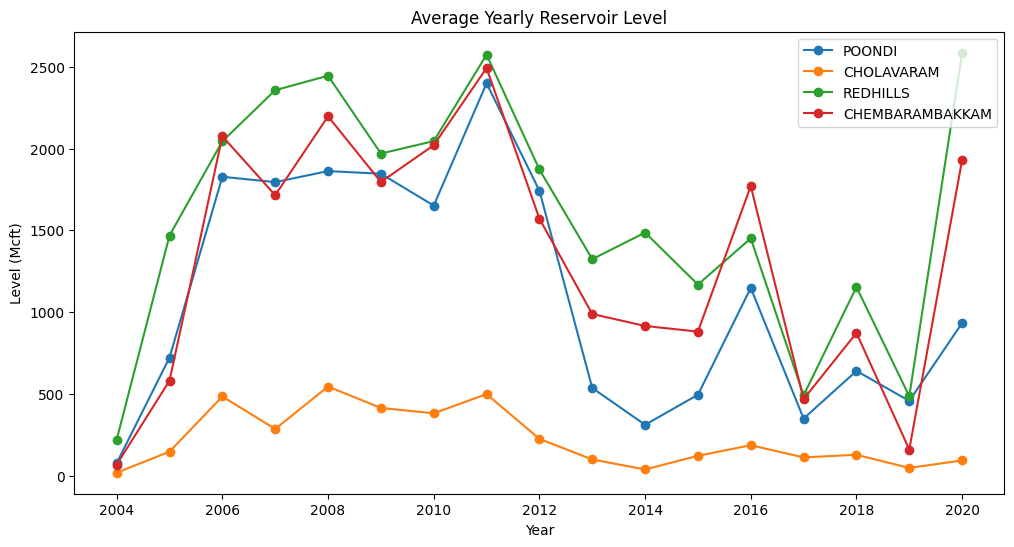

In [55]:
df['Year'] = df['Date'].dt.year
yearly_avg = df.groupby('Year')[reservoirs].mean()

yearly_avg.plot(figsize=(12,6), marker='o')
plt.title('Average Yearly Reservoir Level')
plt.ylabel('Level (Mcft)')
plt.show()

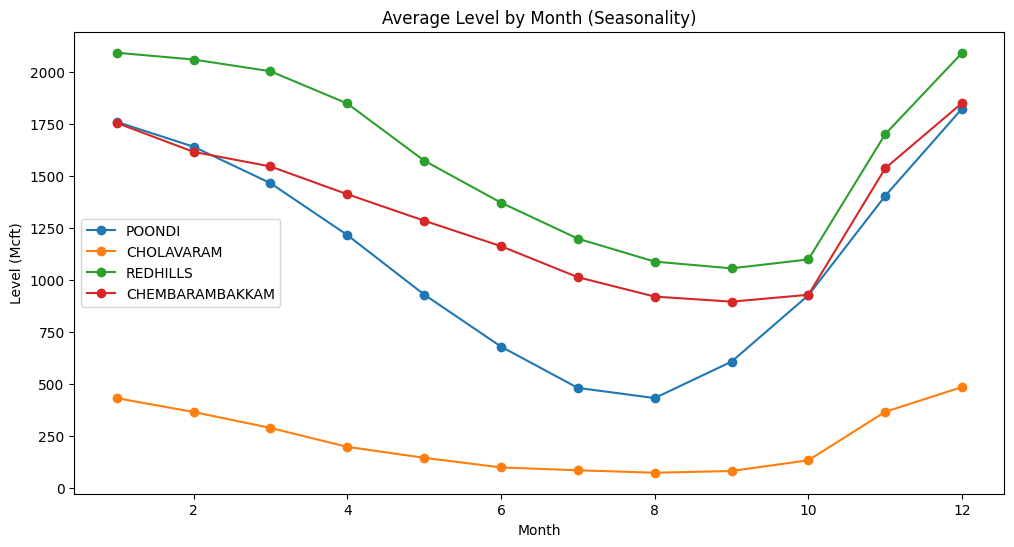

In [56]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')[reservoirs].mean()

monthly_avg.plot(figsize=(12,6), marker='o')
plt.title('Average Level by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Level (Mcft)')
plt.show()

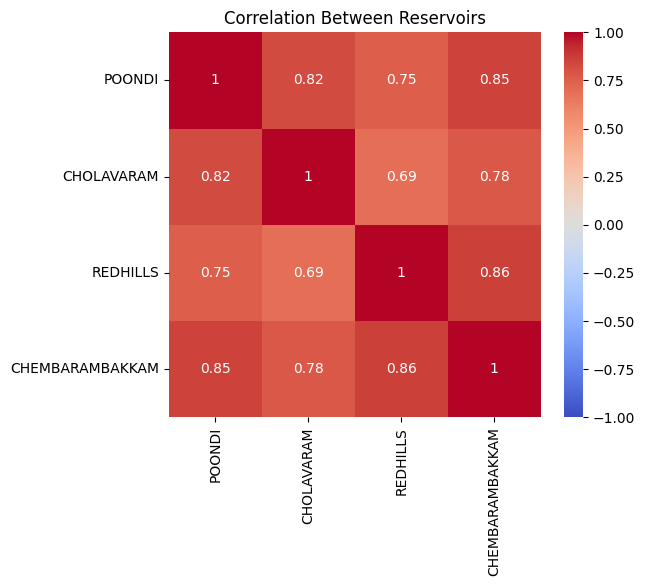

In [57]:
corr = df[reservoirs].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Reservoirs')
plt.show()